In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("data-prep/all_data.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      int64  
 1   Source IP                    int64  
 2   Source Port                  int64  
 3   Destination IP               int64  
 4   Destination Port             int64  
 5   Protocol                     int64  
 6   Timestamp                    int64  
 7   Flow Duration                int64  
 8   Total Fwd Packets            int64  
 9   Total Backward Packets       int64  
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  

In [6]:
df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,External IP
0,82985,22,443,866,54865,6,0,3,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,0.0
1,83017,37,80,866,55054,6,0,109,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,0.0
2,83018,37,80,866,55055,6,0,52,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,0.0
3,57106,45,443,860,46236,6,0,34,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,0.0
4,83023,49,443,866,54863,6,0,3,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,0.0


In [7]:
df.shape

(2830743, 85)

In [8]:
# Identify columns with numeric data types
numeric_columns = df.select_dtypes(include=[np.number]).columns


In [13]:
# Check the rows with NaNs in specific columns
print(df[df.isna().any(axis=1)])


Empty DataFrame
Columns: [Flow ID, Source IP, Source Port, Destination IP, Destination Port, Protocol, Timestamp, Flow Duration, Total Fwd Packets, Total Backward Packets, Total Length of Fwd Packets, Total Length of Bwd Packets, Fwd Packet Length Max, Fwd Packet Length Min, Fwd Packet Length Mean, Fwd Packet Length Std, Bwd Packet Length Max, Bwd Packet Length Min, Bwd Packet Length Mean, Bwd Packet Length Std, Flow Bytes/s, Flow Packets/s, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Total, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Bwd IAT Total, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, Fwd Header Length, Bwd Header Length, Fwd Packets/s, Bwd Packets/s, Min Packet Length, Max Packet Length, Packet Length Mean, Packet Length Std, Packet Length Variance, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count, Down

In [14]:
y = df['Label']
X = df.drop(labels=['Label', 'Flow ID', 'Source IP', 'Source Port',
              'Destination IP', 'Destination Port', 'Protocol', 'Timestamp'], axis=1)


In [36]:
y.describe()

count     2830743
unique         15
top        BENIGN
freq      2273097
Name: Label, dtype: object

In [16]:

X.isnull().values.any()


np.False_

In [22]:
X.shape

(2830743, 77)

In [21]:
y.shape

(2830743,)

In [31]:
print(type(X))  # Should output: <class 'torch.Tensor'>
print(type(y))  # Should output: <class 'torch.Tensor'>


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [25]:
from torch.utils.data import DataLoader, TensorDataset


In [33]:
print(f"y dtype: {y.dtype}")


y dtype: object


Using device: cuda
Number of features (input_size): 84
Number of classes: 15
Starting training...
Epoch [1/10], Step [100/35385], Loss: 0.3220
Epoch [1/10], Step [200/35385], Loss: 0.2755
Epoch [1/10], Step [300/35385], Loss: 0.2330
Epoch [1/10], Step [400/35385], Loss: 0.1179
Epoch [1/10], Step [500/35385], Loss: 0.2448
Epoch [1/10], Step [600/35385], Loss: 0.1726
Epoch [1/10], Step [700/35385], Loss: 0.2392
Epoch [1/10], Step [800/35385], Loss: 0.1746
Epoch [1/10], Step [900/35385], Loss: 0.2729
Epoch [1/10], Step [1000/35385], Loss: 0.1712
Epoch [1/10], Step [1100/35385], Loss: 0.0552
Epoch [1/10], Step [1200/35385], Loss: 0.1467
Epoch [1/10], Step [1300/35385], Loss: 0.1447
Epoch [1/10], Step [1400/35385], Loss: 0.1406
Epoch [1/10], Step [1500/35385], Loss: 0.1908
Epoch [1/10], Step [1600/35385], Loss: 0.1264
Epoch [1/10], Step [1700/35385], Loss: 0.1796
Epoch [1/10], Step [1800/35385], Loss: 0.1588
Epoch [1/10], Step [1900/35385], Loss: 0.2595
Epoch [1/10], Step [2000/35385], Loss

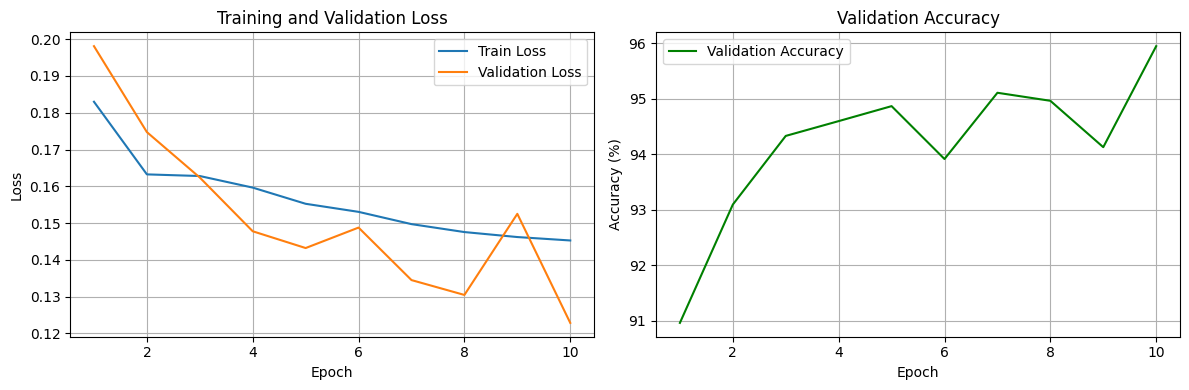

Model saved successfully!


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Prepare data from df
X = df.drop('Label', axis=1).values  # Extract features
input_size = X.shape[1]  # Dynamically set input_size based on number of features
print(f"Number of features (input_size): {input_size}")

label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(df['Label'])  # Encode labels
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")

# Custom Dataset class
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(device)
        self.y = torch.LongTensor(y).to(device)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Bi-LSTM Model
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                          batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.dropout = nn.Dropout(0.2)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)
        
        x = x.unsqueeze(1)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Hyperparameters
hidden_size = 128
num_layers = 2
num_classes = num_classes
batch_size = 64
num_epochs = 10
learning_rate = 0.001

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_numeric, test_size=0.2, random_state=42)

# Create datasets
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

# Create dataloaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model
model = BiLSTM(input_size, hidden_size, num_layers, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store metrics
train_losses = []
val_losses = []
val_accuracies = []

# Training and evaluation function
def train_and_evaluate():
    model.train()
    total_step = len(train_loader)
    
    for epoch in range(num_epochs):
        # Training phase
        epoch_train_loss = 0
        model.train()
        for i, (features, labels) in enumerate(train_loader):
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            
            if (i+1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], '
                      f'Loss: {loss.item():.4f}')
        
        # Average training loss for the epoch
        avg_train_loss = epoch_train_loss / total_step
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for features, labels in val_loader:
                outputs = model(features)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch [{epoch+1}/{num_epochs}] - '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.2f}%')

# Train the model
print("Starting training...")
train_and_evaluate()

# Plotting
plt.figure(figsize=(12, 4))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save the model
torch.save(model.state_dict(), 'bilstm_model.pth')
print("Model saved successfully!")

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for features, labels in val_loader:
        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

ModuleNotFoundError: No module named 'seaborn'